# Lab 5 Mega Test


**Topics from Lab 2, 3, 4:** preprocessing → visualization → linear regression  
**Time:** 60 | **Total:** 100 marks  
**Allowed:** pandas, numpy, matplotlib/seaborn, sklearn  
**Rule:** Write clear code with short comments. Show outputs (tables/plots).

# Dataset (provided)

**File:** `house_linear.csv`  
**Goal:** Predict **`price`** from features (includes at least one categorical column and missing/sentinel values).

## Part A — Data Understanding + Preprocessing (Lab 2) [40 marks]

### Q1. Load and understand the dataset [10]

Do the following and show the output:

1) Show the **first 5 rows** of the dataset.  
2) Show the **shape** of the dataset (rows, columns).  
3) Show the **data types** of each column.  
4) Show **how many missing values** exist per column.

### Q2. Clean missing and bad values [15]
The dataset contains missing values and may contain “sentinel” values (e.g., `-99999`, `"NA"`, `"?"`).

1) Detect and convert any sentinel/bad values to real missing values.  
2) Fill missing values using this rule:
- Numeric columns → fill using **median**
- Categorical columns → fill using `"Unknown"`
3) After cleaning, show missing values per column again to prove it worked.

### Q3. Convert categorical to numeric (One-hot encoding) [15]
1) One-hot encode the categorical column(s) (e.g., `town`).  
2) Ensure the encoded columns are **0/1 numeric** (not True/False).  
3) Create:
- **X** = all input features
- **y** = target column (`price`)

4) Show:
- shape of `X` and `y`
- data types of `X`





In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df= pd.read_csv('house_linear.csv')

In [ ]:
df.head()

,area,bedrooms,age,town,price
0,2122.0,4.0,28.0,monroe township,554200
1,NaN,2.0,4.0,princeton,792500
2,2680.0,4.0,47.0,west windsor,659800
3,3223.0,5.0,20.0,princeton,866900
4,2761.0,5.0,17.0,edison,753400


In [ ]:
df.shape

(180, 5)

In [ ]:
df.dtypes

,0
area,float64
bedrooms,float64
age,float64
town,object
price,int64


In [ ]:
df.isnull().sum()

,0
area,8
bedrooms,7
age,6
town,9
price,0


In [ ]:
df.replace([-99999, "NA", "?", "na"], np.nan, inplace=True)

In [ ]:
num_cols=df.select_dtypes(include=np.number).columns
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)
cat_cols=df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col].fillna('Unknown', inplace=True)

In [ ]:
df.isnull().sum()

,0
area,0
bedrooms,0
age,0
town,0
price,0


In [ ]:
df_encoder = pd.get_dummies(df,columns=cat_cols,dtype=int)
df_encoder.head()

,area,bedrooms,age,price,town_Unknown,town_edison,town_monroe township,town_princeton,town_robinsville,town_west windsor
0,2122.0,4.0,28.0,554200,0,0,1,0,0,0
1,2982.0,2.0,4.0,792500,0,0,0,1,0,0
2,2680.0,4.0,47.0,659800,0,0,0,0,0,1
3,3223.0,5.0,20.0,866900,0,0,0,1,0,0
4,2761.0,5.0,17.0,753400,0,1,0,0,0,0


In [ ]:
y = df_encoder['price']
x = df_encoder.drop('price',axis=1)

In [ ]:
x.shape

(180, 9)

In [ ]:
y.shape

(180,)

In [ ]:
x.dtypes

,0
area,float64
bedrooms,float64
age,float64
town_Unknown,int64
town_edison,int64
town_monroe township,int64
town_princeton,int64
town_robinsville,int64
town_west windsor,int64


In [ ]:
y.dtypes

dtype('int64')

## Part B — Statistics + Visualization (Lab 3) [25 marks]

### Q4. Summary statistics [10]
For **`area`** and **`price`**, compute and show:
- mean, median, standard deviation  
- Q1, Q3, and IQR (Q3 − Q1)


### Q5. Outlier detection [10]
Using **price only**, identify outliers using BOTH:
1) **±3σ rule**  

Show:
- number of outliers found
- the outlier values (or their row indices)


### Q6. Visualization (choose any 2) [5]
Create any **two** plots (must include title + labeled axes):
- Histogram or KDE plot of `price`
- Scatter plot of `area` vs `price`
- Correlation heatmap (numeric columns only)


In [ ]:
area=df['area']
price=df['price']
print('mean of area:',area.mean())
print('median of area:',area.median())
print('standard deviation of area:',area.std())

print('mean of price:',price.mean())
print('median of price:',price.median())
print('standard deviation of price:',price.std())

mean of area: 2982.561111111111
median of area: 2982.0
standard deviation of area: 414.2771609405601
mean of price: 733960.9722222222
median of price: 725000.0
standard deviation of price: 108090.09133831078


In [ ]:
q1_area=area.quantile(0.25)
q3_area=area.quantile(0.75)
iqr_area=q3_area-q1_area
print('Q1 of area:',q1_area)
print('Q3 of area:',q3_area)
print('IQR of area:',iqr_area)

Q1 of area: 2728.0
Q3 of area: 3283.75
IQR of area: 555.75


In [ ]:
q1_price=price.quantile(0.25)
q3_price=price.quantile(0.75)
iqr_price=q3_price-q1_price
print('Q1 of price:',q1_price)
print('Q3 of price:',q3_price)
print('IQR of price:',iqr_price)

Q1 of price: 670825.0
Q3 of price: 788450.0
IQR of price: 117625.0


In [ ]:
price_mean=price.mean()
price_std=price.std()

lower_3s = price_mean - 3 * price_std
upper_3s = price_mean + 3 * price_std
outliers_3s = df[(price < lower_3s) | (price > upper_3s)]
print("Number of outliers:", len(outliers_3s))
print("Outlier value:", outliers_3s.index.tolist())

Number of outliers: 2
Outlier value: [17, 126]


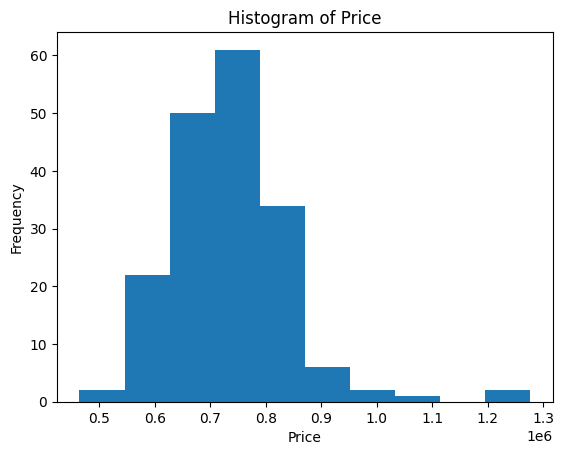

In [ ]:
plt.hist(price,bins=10)
plt.title('Histogram of Price')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

<Axes: xlabel='price', ylabel='Density'>

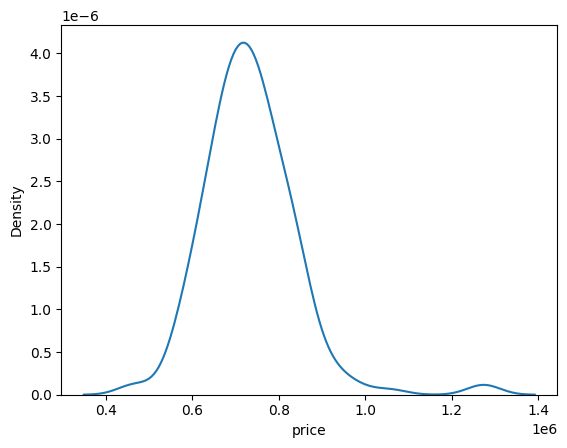

In [ ]:
sns.kdeplot(price)

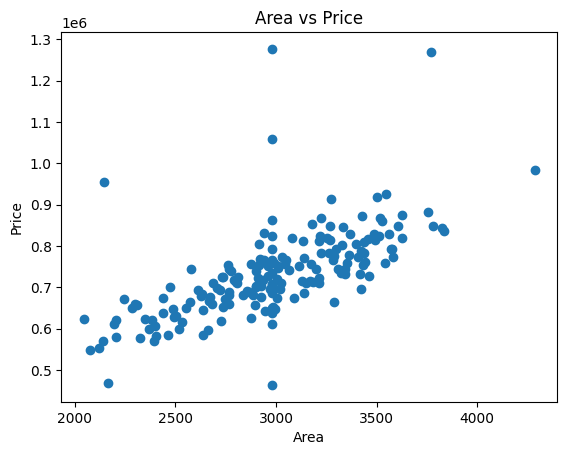

In [ ]:
plt.scatter(df["area"], df["price"])
plt.title("Area vs Price")
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

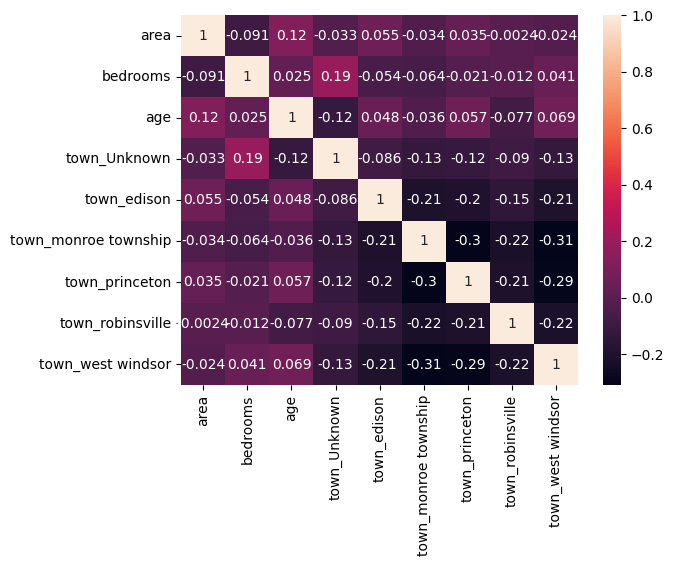

In [ ]:
sns.heatmap(x.corr(),annot=True)
plt.show()

## Part C — Machine Learning Model (Lab 4: Linear Regression) [35 marks]

### Q7. Feature scaling [10]
Scale numeric features in **X** using **one** method:
- Min–Max normalization **OR**
- Standardization (z-score)

Add 1–2 short comment lines explaining why you chose it.



### Q8. Train a Linear Regression model [15]
1) Split your data into **training and testing** sets (80/20).  
2) Train a **Linear Regression** model using the training set.  
3) Show:
- intercept (bias)
- coefficients (weights)


In [ ]:
from sklearn.model_selection import train_test_split as tts
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler,StandardScaler

In [ ]:
minmax= MinMaxScaler()
x_minmax=minmax.fit_transform(x)

In [ ]:
ss=StandardScaler()
x_ss=ss.fit_transform(x)

In [ ]:
x_train,x_test,y_train,y_test=tts(x,y,test_size=0.3,random_state=45)

In [ ]:
reg= LinearRegression()

In [ ]:
reg.fit(x_train,y_train)

LinearRegression()

In [ ]:
reg.score(x_train,y_train)

0.510982758739819

In [ ]:
reg.score(x_test,y_test)

0.8910553544579676

In [ ]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [ ]:
y_pred=reg.predict(x_test)

In [ ]:
mse = mean_squared_error(y_test,y_pred)
mse

794089118.495714

In [ ]:
mae=mean_absolute_error(y_test,y_pred)
mae

23746.882250047085

In [ ]:
r2_score=r2_score(y_test,y_pred)
r2_score

0.8910553544579676

In [ ]:
reg.intercept_

np.float64(108141.79747207998)

In [ ]:
reg.coef_

array([   184.20216779,  32085.29228861,  -1351.92329322,  -6653.63366665,
       -30572.4409819 , -22037.11751353,  39619.08486247, -16256.66924709,
        35900.7765467 ])

## Submission
Submit notebook as: **`Lab5_SetA_Name_ID_Section.ipynb`**  
Notebook must run from top to bottom without errors.